In [16]:
import torch
from colpali_engine.models import ColIdefics3, ColIdefics3Processor
from transformers import AutoModel, AutoProcessor, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

from transformers.utils.import_utils import is_flash_attn_2_available
from colpali_engine.models import ColQwen2, ColQwen2Processor

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from umap import UMAP


In [115]:
model_name = "vidore/colSmol-256M"
processor = ColIdefics3Processor.from_pretrained(model_name)
model = ColIdefics3.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="mps",
).eval()

In [116]:
#from vidore_benchmark.utils.data_utils import deduplicate_dataset_rows

# Evaluate on a single dataset
#ds = load_dataset("vidore/tabfquad_test_subsampled", split="test[:10]")
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)
#ds_queries = deduplicate_dataset_rows(ds=ds_queries, target_column='query')

queries = list(ds_queries['query'])

dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
    collate_fn=processor.process_queries
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        batch_query = batch_query.to(model.device)
        embeddings_query = model(**batch_query).to("cpu")
        #print(f"input:{batch_query['input_ids'].shape}")
        #print(f"output {embeddings_query.shape}")
        query_embeddings.extend(list(torch.unbind(embeddings_query)))



In [56]:
queries

['What is the process for manually labeling trial data in Vicon Nexus?',
 'What is the micromort, and how is it used in safety analysis?',
 'What is the difference between the straw-man and baseline single-tree update experiments?',
 'What commands can be used to display system settings and configurations?',
 'What are some alternative terms used for Bayesian networks mentioned in the text?',
 "What did Benjamin Wellington's 2007 PhD thesis at New York University focus on?",
 'What is the typical process of the ETTAP program as depicted in the image?',
 'How can the orientation of texture be characterized?',
 'What type of motion capture cameras can be integrated into the Vicon MX T-Series system?',
 'What are some of the challenges faced by automotive manufacturers, suppliers, and distributors as described in the passage?',
 'How can you create a web collection in the DL browser?',
 'What was the issue with the initial design of the cotton harvesting system and how was it addressed?',

In [117]:
passages = list(ds_passages['image'])

dataloader = DataLoader(
    dataset=passages,
    batch_size=1,
    shuffle=False,
    collate_fn=processor.process_images
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(dataloader, desc="Forward pass images...", leave=False):
        batch_doc = batch_doc.to(torch.float32).to(model.device)
        embeddings_doc = model(**batch_doc).to("cpu")
        #print(embeddings_doc.shape)
        image_embeddings.extend(list(torch.unbind(embeddings_doc)))


In [118]:
suffix = 'colSmol-256M-vidore-arxivqa-test-100samples'
torch.save(query_embeddings, f"query_embeddings_{suffix}.pt")
torch.save(image_embeddings, f"passage_embeddings_{suffix}.pt")


In [20]:
suffix = 'colSmol-256M-vidore-arxivqa-test-100samples'
query_embeddings = torch.load(f"query_embeddings_{suffix}.pt")
image_embeddings = torch.load(f"passage_embeddings_{suffix}.pt")

In [21]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]

In [22]:
# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

# Combine and label data
group1_combined = np.concatenate([t.float() for t in group1], axis=0)  # Shape: [N1, 128]
group2_combined = np.concatenate([t.float() for t in group2], axis=0)  # Shape: [N2, 128]

X = np.concatenate([group1_combined, group2_combined], axis=0)

# t-SNE transformation
tsne = TSNE(n_components=2, perplexity=25, random_state=42)
X_embedded = tsne.fit_transform(X)



In [29]:
len(X)

108886

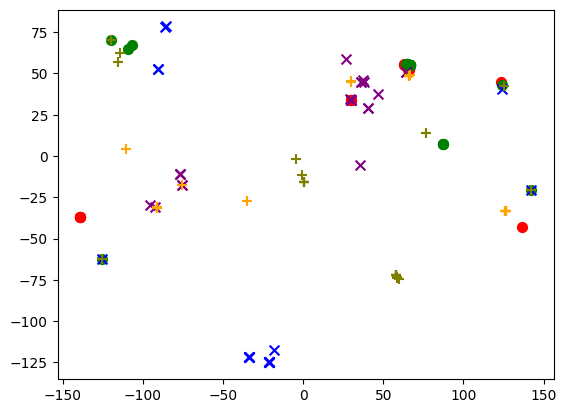

In [43]:
# Visualization with distinct colors
"""labels = np.array([0]*len(group1_combined) + [1]*len(group2_combined))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=0.5,
    edgecolors='w',
    linewidth=0.5
)

# Create legend with group labels
legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Image Embeddings', 'Query Embeddings'],
)
#plt.title('t-SNE Visualization of Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(alpha=0.2) """


index_start_img = 0
index_start_query = 0
color_img = ['red', 'purple', 'orange']
color_query = ['green', 'blue', 'olive']
markers = ['o', 'x', '+']
plot_length = 3
for ind, clr_img, clr_qry, marker in zip([0,1,2][:plot_length], color_img[:plot_length], color_query[:plot_length], markers[:plot_length]):

    # Calculate cosine similarity
    q_embeddings = query_embeddings[ind].float().numpy()
    p_embeddings = image_embeddings[ind].float().numpy()

    result = np.zeros((q_embeddings.shape[0], p_embeddings.shape[0]))
    for i, qe in enumerate(q_embeddings):
        for j, pe in enumerate(p_embeddings):
            result[i, j] = np.dot(qe, pe) #/ (np.linalg.norm(qe) * np.linalg.norm(pe))
    img_indices = np.argmax(result, axis=1) + index_start_query

    index_start_img += len(image_embeddings[ind])
    x_points = X_embedded[img_indices,0]
    y_points = X_embedded[img_indices,1]
    plt.scatter(x_points, y_points, color=clr_img, s=50, marker=marker, label='Highlighted Point', alpha=1)

    # Query embeddings starting index:
    q_starting_ind = len(group1_combined) +index_start_query
    q_end_ind = len(group1_combined) + index_start_query + len(query_embeddings[ind])
    index_start_query += len(query_embeddings[ind])
    x_points = X_embedded[q_starting_ind:q_end_ind,0]
    y_points = X_embedded[q_starting_ind:q_end_ind,1]
    plt.scatter(x_points, y_points, color=clr_qry, s=50, marker = marker, label='Highlighted Point', alpha=1)


#plt.show()
plt.savefig('colsmol_tsne_only3queries.pdf')

In [44]:
device = 'mps'
model = AutoModel.from_pretrained('jinaai/jina-clip-v2', trust_remote_code=True, device_map=device)



/Users/bhasircioglu/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/51f02de9f2cf8afcd3bac4ce996859ba96f9f8e9/modeling_clip.py:137: UserWarning: Flash attention requires CUDA, disabling
  warnings.warn('Flash attention requires CUDA, disabling')
/Users/bhasircioglu/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/51f02de9f2cf8afcd3bac4ce996859ba96f9f8e9/modeling_clip.py:172: UserWarning: xFormers requires CUDA, disabling
  warnings.warn('xFormers requires CUDA, disabling')


In [45]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)

queries = list(ds_queries['query'])
passages = list(ds_passages['image'])

#####

dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        embeddings_query = model.encode_text(batch_query, truncate_dim=128)
        query_embeddings.append(np.array(embeddings_query))

query_embeddings = np.array(query_embeddings)
query_embeddings = query_embeddings[:,0,:]


dataloader = DataLoader(
    dataset=passages,
    batch_size=2,
    shuffle=False,
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(passages, desc="Forward pass images...", leave=False):
        embeddings_doc = model.encode_image(batch_doc.resize((512,512)), truncate_dim=128)
        image_embeddings.append(np.array(embeddings_doc))

image_embeddings = np.array(image_embeddings)



In [46]:
image_mat = np.array(image_embeddings)
query_mat = np.array(query_embeddings)

scores = np.matmul(query_mat, image_mat.T)

counter = 0
for i in range(len(scores)):
    j = np.argmax(scores[i])
    if not i==j and scores[i][j] > scores[i][i]:
        counter += 1
        print(f"query:{i} ({scores[i][i]}), best image index: {j}, {scores[i][j]}")

print(f"counter: {counter}")

query:1 (0.2416006326675415), best image index: 71, 0.3512454628944397
query:11 (0.2624913454055786), best image index: 16, 0.3101206421852112
query:12 (0.3411577641963959), best image index: 61, 0.43869614601135254
query:14 (0.298908531665802), best image index: 12, 0.39350807666778564
query:19 (0.356486976146698), best image index: 30, 0.3623686134815216
query:36 (0.3480015993118286), best image index: 30, 0.3839694559574127
query:42 (0.3095310628414154), best image index: 6, 0.3952840268611908
query:44 (0.3394760489463806), best image index: 5, 0.40428778529167175
query:45 (0.3266405463218689), best image index: 61, 0.405899316072464
query:48 (0.3073044717311859), best image index: 16, 0.32537567615509033
query:56 (0.2652759552001953), best image index: 89, 0.3574354946613312
query:58 (0.24919183552265167), best image index: 27, 0.2995588183403015
query:64 (0.30094555020332336), best image index: 61, 0.42608579993247986
query:76 (0.3863676190376282), best image index: 16, 0.39066362

In [47]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]

# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

X = np.concatenate([group1, group2], axis=0)


In [48]:
# t-SNE transformation
tsne = TSNE(n_components=2, perplexity=25, random_state=42)
X_embedded = tsne.fit_transform(X)

In [10]:
umap_model = UMAP(
    n_components=2,
    n_neighbors=25,        # Controls local vs global structure balance
    min_dist=0.1,          # Minimum distance between embedded points
    metric='cosine',    # Distance metric (adjust based on data)
    random_state=42
)
X_embedded = umap_model.fit_transform(X)

/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/bhasircioglu/mumoRAG-attacks/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


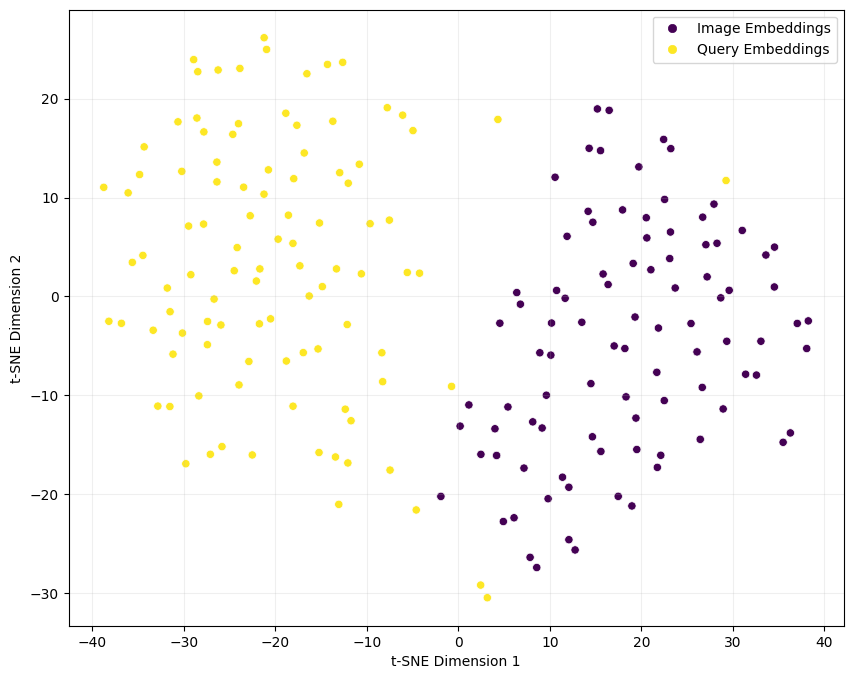

<Figure size 640x480 with 0 Axes>

In [50]:
# Visualization with distinct colors
labels = np.array([0]*len(group1) + [1]*len(group2))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=1,
    edgecolors='w',
    linewidth=0.5
)

# Create legend with group labels
legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Image Embeddings', 'Query Embeddings'],
)
#plt.title('t-SNE Visualization of Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(alpha=0.2)

"""index_ui = 1
x_points = X_embedded[index_ui,0]
y_points = X_embedded[index_ui,1]
plt.scatter(x_points, y_points, color='red', s=10, label='Highlighted Point', alpha=1)

best_match_id = 71
x_points = X_embedded[best_match_id,0]
y_points = X_embedded[best_match_id,1]
plt.scatter(x_points, y_points, color='blue', s=10, label='Highlighted Point', alpha=1)

# Query embeddings starting index:
q_starting_ind = len(group1)
x_points = X_embedded[q_starting_ind+index_ui,0]
y_points = X_embedded[q_starting_ind+index_ui,1]
plt.scatter(x_points, y_points, color='green', s=10, label='Highlighted Point', alpha=1)"""


plt.show()
plt.savefig('jina_tsne_noQuery.pdf')

In [51]:
device = 'mps'
model_name = "openai/clip-vit-large-patch14"
model = AutoModel.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name, use_fast=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [52]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split="test[:100]")

ds = ds.map(lambda example, idx: {'id': idx}, with_indices=True)

ds_passages = ds.remove_columns(
    [col for col in ds.column_names if col not in ['image', 'image_hash', 'id']]
)
ds_queries = ds.remove_columns(
    [col for col in ds.column_names if col not in ['query', 'id']]
)

queries = list(ds_queries['query'])
passages = list(ds_passages['image'])

#####
dataloader = DataLoader(
    dataset=queries,
    batch_size=1,
    shuffle=False,
)

query_embeddings = []

with torch.no_grad():
    for batch_query in tqdm(dataloader, desc="Forward pass queries...", leave=False):
        embeddings_query = model.get_text_features(**tokenizer(batch_query, return_tensors="pt", truncation=True, padding=True).to(device)) 
        query_embeddings.append(embeddings_query.to('cpu').numpy())

query_embeddings = np.array(query_embeddings)
query_embeddings = query_embeddings[:,0,:]


dataloader = DataLoader(
    dataset=passages,
    batch_size=2,
    shuffle=False,
)

image_embeddings = []

with torch.no_grad():
    for batch_doc in tqdm(passages, desc="Forward pass images...", leave=False):
        image_input_emb = processor(images=batch_doc, return_tensors='pt').to(device)

        embeddings_doc = model.get_image_features(**image_input_emb)
        #embeddings_doc = model.encode_image(batch_doc.resize((512,512)), truncate_dim=128)
        image_embeddings.append(embeddings_doc.to('cpu').numpy())

image_embeddings = np.array(image_embeddings)
image_embeddings = image_embeddings[:,0,:]


In [53]:
#Permuting embeddings:
perm = np.random.permutation(len(query_embeddings))
query_embeddings = [query_embeddings[i] for i in perm]
image_embeddings = [image_embeddings[i] for i in perm]

# Sample data: group1 and group2 are lists of [1, X, 128] tensors
group1 = image_embeddings
group2 = query_embeddings

X = np.concatenate([group1, group2], axis=0)

# t-SNE transformation
tsne = TSNE(n_components=2, perplexity=25, random_state=42)
X_embedded = tsne.fit_transform(X)



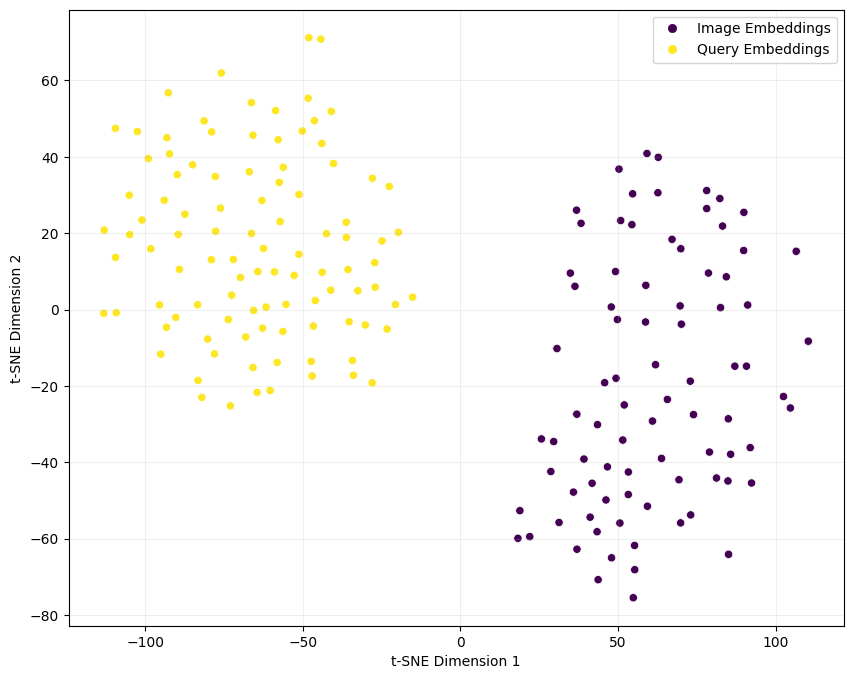

<Figure size 640x480 with 0 Axes>

In [55]:
# Visualization with distinct colors
labels = np.array([0]*len(group1) + [1]*len(group2))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=1,
    edgecolors='w',
    linewidth=0.5
)

# Create legend with group labels
legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Image Embeddings', 'Query Embeddings'],
)
#plt.title('t-SNE Visualization of Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(alpha=0.2)


"""x_points = X_embedded[0,0]
y_points = X_embedded[0,1]
plt.scatter(x_points, y_points, color='red', s=10, label='Highlighted Point', alpha=1)

# Query embeddings starting index:
q_starting_ind = len(group1)
x_points = X_embedded[q_starting_ind,0]
y_points = X_embedded[q_starting_ind,1]
plt.scatter(x_points, y_points, color='green', s=10, label='Highlighted Point', alpha=1)"""


plt.show()
plt.savefig('clip14_tsne_noQuery.pdf')